# Harmonic analysis of air temperature

This notebook fits a low-order harmonic model to air temperature from xarray's `air_temperature` tutorial dataset.

We will look at both a single local record and the full spatial field.


## 1. Harmonic model

We approximate the time series with a truncated real Fourier expansion,

$$
x(t) = \overline{x} + \sum_{k=1}^{K}\left[a_k \cos\left(\frac{2\pi k t}{P}\right) + b_k \sin\left(\frac{2\pi k t}{P}\right)\right].
$$

Here $P$ is the fundamental period and $K$ is the highest retained harmonic. For datetime-like coordinates, `fundamental_period=None` means the fundamental period is one year, so `harmonic=1` is annual and `harmonic=2` is semiannual.


## 2. Imports


In [1]:
import xarray as xr
import xharmonics as xh
import matplotlib.pyplot as plt


## 3. Load the dataset


In [2]:
ds = xr.tutorial.load_dataset("air_temperature")
ds


<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

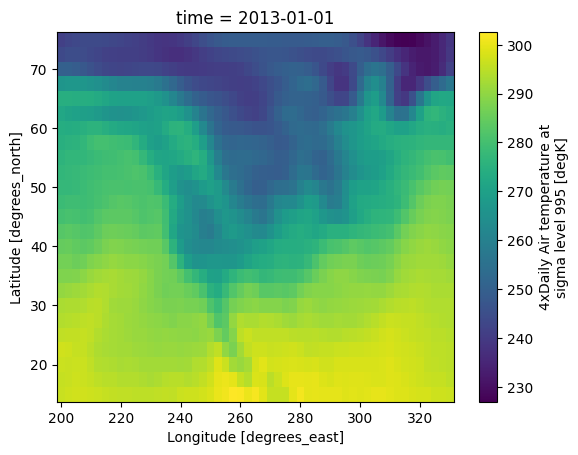

In [3]:
ds.isel(time=0).air.plot()


## 4. Local harmonic fit

We begin with one grid point so the meaning of the harmonic decomposition is easy to see.


In [4]:
da = ds["air"].sel(lat=40.0, lon=250.0, method="nearest")
da.name = "air"
da


<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([262.1 , 255.6 , 256.6 , ..., 255.09, 252.69, 254.59], shape=(2920,))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat      float32 4B 40.0
    lon      float32 4B 250.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

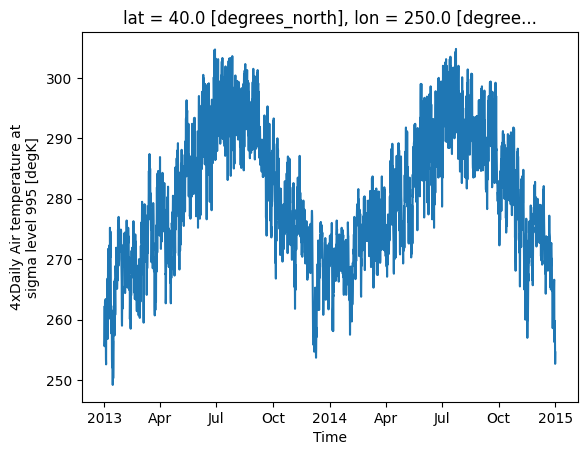

In [5]:
da.plot()


## 5. Fit harmonic coefficients

We retain the mean, annual, and semiannual terms by choosing `n_harmonics=2`.


In [6]:
coef_ds = xh.fit(da, time_dim="time", n_harmonics=2)
coef_ds


<xarray.Dataset> Size: 128B
Dimensions:   (harmonic: 3, basis: 2)
Coordinates:
  * harmonic  (harmonic) int64 24B 0 1 2
  * basis     (basis) <U3 24B 'cos' 'sin'
    lat       float32 4B 40.0
    lon       float32 4B 250.0
Data variables:
    coef      (harmonic, basis) float64 48B 280.5 0.0 -12.46 -4.589 0.3137 1.608
    phase     (harmonic) float64 24B 0.0 -2.789 1.378
Attributes: (12/14)
    xharmonics:                   fit
    time_dim:                     time
    fundamental_period:           1.0
    fundamental_period_units:     years for datetime-like coordinates; native...
    fundamental_period_inferred:  True
    n_harmonics:                  2
    ...                           ...
    sampling_frequency_inferred:  True
    time_origin:                  2013-01-01T00:00:00.000000000
    weighted:                     False
    time_kind:                    datetime-like
    calendar:                     proleptic_gregorian
    units:                        degK

The output stores the real Fourier coefficients in `coef` and the corresponding `phase`. The mean is encoded as `harmonic=0`.


In [7]:
energy = (coef_ds["coef"] ** 2).sum("basis")
energy.name = "energy"
energy


<xarray.DataArray 'energy' (harmonic: 3)> Size: 24B
array([7.86536528e+04, 1.76291562e+02, 2.68345874e+00])
Coordinates:
  * harmonic  (harmonic) int64 24B 0 1 2
    lat       float32 4B 40.0
    lon       float32 4B 250.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]
    description:   Harmonic coefficients indexed by real Fourier basis. coef....

To reconstruct the fitted signal, evaluate the coefficients on the desired time axis:

$$
\mathrm{fit}_k(t) = a_k \cos\left(\frac{2\pi k t}{P}\right) + b_k \sin\left(\frac{2\pi k t}{P}\right).
$$


In [8]:
fit_da = xh.evaluate(coef_ds, time=da["time"], time_dim="time")

annual_fit = fit_da.sel(harmonic=1)
semiannual_fit = fit_da.sel(harmonic=2)
seasonal_fit = fit_da.sum("harmonic")
residual = da - seasonal_fit

fit_da


<xarray.DataArray 'fit' (harmonic: 3, time: 2920)> Size: 70kB
array([[ 2.80452586e+02,  2.80452586e+02,  2.80452586e+02, ...,
         2.80452586e+02,  2.80452586e+02,  2.80452586e+02],
       [-1.24592269e+01, -1.24788476e+01, -1.24982376e+01, ...,
        -1.23589265e+01, -1.23796820e+01, -1.24002086e+01],
       [ 3.13665510e-01,  3.27483187e-01,  3.41276637e-01, ...,
         2.45085462e-01,  2.59007797e-01,  2.72910969e-01]],
      shape=(3, 2920))
Coordinates:
  * harmonic  (harmonic) int64 24B 0 1 2
  * time      (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat       float32 4B 40.0
    lon       float32 4B 250.0
Attributes: (12/14)
    long_name:           4xDaily Air temperature at sigma level 995
    units:               degK
    precision:           2
    GRIB_id:             11
    GRIB_name:           TMP
    var_desc:            Air temperature
    ...                  ...
    statistic:           Individual Obs
    parent_stat:         Other
    actual_range:        [185.16 322.1 ]
    formula:             fit[k,t] = a_k cos(2*pi*k*t/fundamental_period) + b_...
    fundamental_period:  1.0
    time_origin:         2013-01-01T00:00:00.000000000

`fit_da` stores one reconstructed contribution per harmonic:

- `harmonic=0`: mean,
- `harmonic=1`: annual,
- `harmonic=2`: semiannual.


## 6. Oscillatory harmonics and harmonic energy

To focus on the seasonal oscillations, we drop the mean and compare the reconstructed oscillatory harmonics with the derived energy-like quantity $a_k^2 + b_k^2$.


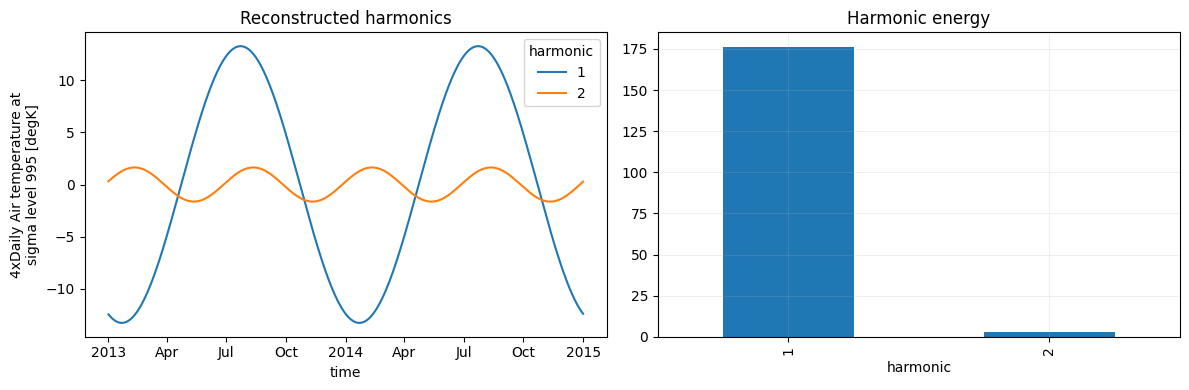

In [9]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

fit_da.sel(harmonic=slice(1, None)).plot(hue="harmonic", ax=axes[0])
axes[0].set_title("Reconstructed harmonics")

energy.sel(harmonic=slice(1, None)).to_series().plot.bar(ax=axes[1])
axes[1].set_title("Harmonic energy")
axes[1].grid(alpha=0.2)

plt.tight_layout()


## 7. Original record, seasonal fit, and residual

This is the main diagnostic: it shows what the low-order harmonic model captures and what remains after the seasonal fit is removed.


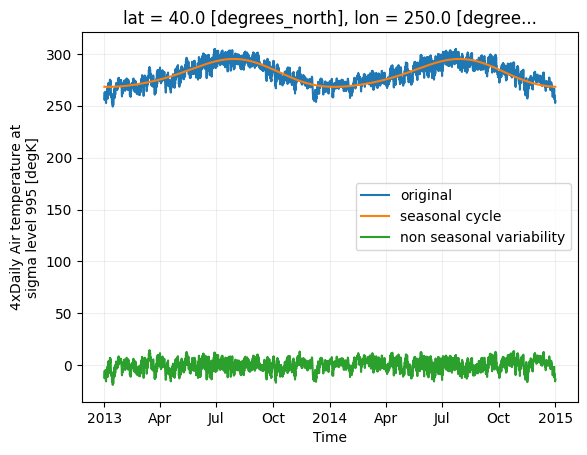

In [10]:
da.plot(label="original")
seasonal_fit.plot(label="seasonal cycle")
residual.plot(label="non seasonal variability")
plt.grid(alpha=0.2)
plt.legend()


## 8. Spatial harmonic energy

The same fit can be applied to the full field because `air` is still a `DataArray`; the fit is carried out independently at each grid point along the shared time dimension.

Below we compare the spatial distribution of harmonic energy for the annual and semiannual components.


Text(0.5, 1.0, 'Semiannual harmonic energy')

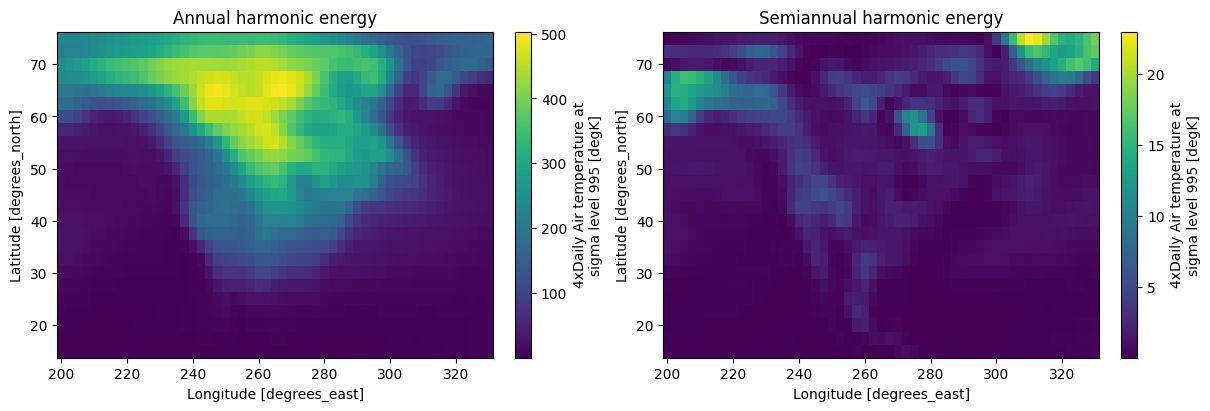

In [11]:
coef_map = xh.fit(ds["air"], time_dim="time", n_harmonics=2)
energy_map = (coef_map["coef"] ** 2).sum("basis")

fig, axes = plt.subplots(ncols=2, figsize=(12, 4), constrained_layout=True)

energy_map.sel(harmonic=1).plot(ax=axes[0])
axes[0].set_title("Annual harmonic energy")

energy_map.sel(harmonic=2).plot(ax=axes[1])
axes[1].set_title("Semiannual harmonic energy")


In [14]:
xh.evaluate(coef_map, ds["time"])

<xarray.DataArray 'fit' (harmonic: 3, time: 2920, lat: 25, lon: 53)> Size: 93MB
array([[[[ 2.60376442e+02,  2.60183051e+02,  2.59886627e+02, ...,
           2.50815901e+02,  2.51938116e+02,  2.53438048e+02],
         [ 2.62734394e+02,  2.62793976e+02,  2.62749339e+02, ...,
           2.49755904e+02,  2.51585757e+02,  2.54359260e+02],
         [ 2.64768764e+02,  2.64327308e+02,  2.64061695e+02, ...,
           2.50607890e+02,  2.53583510e+02,  2.57715599e+02],
         ...,
         [ 2.97649863e+02,  2.96953332e+02,  2.96629315e+02, ...,
           2.96810925e+02,  2.96287962e+02,  2.95816455e+02],
         [ 2.98129202e+02,  2.97937007e+02,  2.97470394e+02, ...,
           2.96859548e+02,  2.96777027e+02,  2.96443836e+02],
         [ 2.98366151e+02,  2.98385740e+02,  2.98114144e+02, ...,
           2.97338205e+02,  2.97281445e+02,  2.97305103e+02]],

        [[ 2.60376442e+02,  2.60183051e+02,  2.59886627e+02, ...,
           2.50815901e+02,  2.51938116e+02,  2.53438048e+02],
         [ 2.62734394e+02,  2.62793976e+02,  2.62749339e+02, ...,
           2.49755904e+02,  2.51585757e+02,  2.54359260e+02],
         [ 2.64768764e+02,  2.64327308e+02,  2.64061695e+02, ...,
           2.50607890e+02,  2.53583510e+02,  2.57715599e+02],
...
          -3.18677430e-01, -3.38709597e-01, -3.93313904e-01],
         [-2.50282638e-01, -2.89634153e-01, -3.01705391e-01, ...,
          -3.49679568e-01, -3.43229261e-01, -3.99012639e-01],
         [-2.26026180e-01, -2.51284530e-01, -2.40775469e-01, ...,
          -2.95580976e-01, -2.74280057e-01, -3.08304340e-01]],

        [[-1.39086060e-02,  1.62418297e-01,  3.53877223e-01, ...,
           3.49461384e+00,  3.70111665e+00,  3.88641984e+00],
         [-1.15193756e+00, -1.02293373e+00, -8.68596848e-01, ...,
           3.37024055e+00,  3.59632682e+00,  3.70874852e+00],
         [ 4.55485929e-01,  8.48824700e-01,  1.12938933e+00, ...,
           3.55288943e+00,  3.46752728e+00,  3.19390949e+00],
         ...,
         [-1.79256873e-01, -2.37753445e-01, -2.68948118e-01, ...,
          -3.21433187e-01, -3.41673521e-01, -3.96602697e-01],
         [-2.52148150e-01, -2.91361802e-01, -3.02977274e-01, ...,
          -3.53297961e-01, -3.47072848e-01, -4.03116668e-01],
         [-2.27656650e-01, -2.52644860e-01, -2.41893087e-01, ...,
          -2.98841546e-01, -2.77780342e-01, -3.12005426e-01]]]],
      shape=(3, 2920, 25, 53))
Coordinates:
  * harmonic  (harmonic) int64 24B 0 1 2
  * time      (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat       (lat) float32 100B 75.0 72.5 70.0 67.5 ... 22.5 20.0 17.5 15.0
  * lon       (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes: (12/14)
    long_name:           4xDaily Air temperature at sigma level 995
    units:               degK
    precision:           2
    GRIB_id:             11
    GRIB_name:           TMP
    var_desc:            Air temperature
    ...                  ...
    statistic:           Individual Obs
    parent_stat:         Other
    actual_range:        [185.16 322.1 ]
    formula:             fit[k,t] = a_k cos(2*pi*k*t/fundamental_period) + b_...
    fundamental_period:  1.0
    time_origin:         2013-01-01T00:00:00.000000000